In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18
import time
import os


def make_cifar_resnet18(num_classes=10):
    """
    Adapt ResNet-18 for CIFAR-10's 32x32 images.
    Changes from standard ResNet-18:
      - First conv: 3x3 kernel, stride 1, padding 1 (instead of 7x7, stride 2)
      - Remove initial max pooling
    This is the standard adaptation used in adversarial robustness literature.
    """
    model = resnet18(weights=None, num_classes=num_classes)

    # Replace first conv layer
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)

    # Remove maxpool by replacing with identity
    model.maxpool = nn.Identity()

    return model


def main():
    # --- Hyperparameters ---
    batch_size = 128
    epochs = 50
    lr = 0.1
    momentum = 0.9
    weight_decay = 5e-4
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # --- Data ---
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        # No normalization — we want pixel values in [0, 1] for the attack later
    ])

    transform_test = transforms.Compose([
        transforms.ToTensor(),
    ])

    print("Downloading CIFAR-10 (if needed)...")
    trainset = torchvision.datasets.CIFAR10(
        root="./data", train=True, download=True, transform=transform_train
    )
    trainloader = torch.utils.data.DataLoader(
        trainset, batch_size=batch_size, shuffle=True, num_workers=2
    )

    testset = torchvision.datasets.CIFAR10(
        root="./data", train=False, download=True, transform=transform_test
    )
    testloader = torch.utils.data.DataLoader(
        testset, batch_size=batch_size, shuffle=False, num_workers=2
    )

    # --- Model ---
    model = make_cifar_resnet18(num_classes=10)
    model = model.to(device)
    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

    # --- Training setup ---
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)

    # Learning rate schedule: drop by 10x at epochs 20 and 35
    scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[20, 35, 45], gamma=0.1)

    # --- Training loop ---
    print(f"\nTraining for {epochs} epochs...\n")
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        start = time.time()

        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        scheduler.step()
        train_acc = 100.0 * correct / total
        elapsed = time.time() - start

        # Test accuracy every 5 epochs
        if (epoch + 1) % 5 == 0 or epoch == 0:
            model.eval()
            test_correct = 0
            test_total = 0
            with torch.no_grad():
                for inputs, labels in testloader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    _, predicted = outputs.max(1)
                    test_total += labels.size(0)
                    test_correct += predicted.eq(labels).sum().item()
            test_acc = 100.0 * test_correct / test_total
            print(
                f"Epoch {epoch+1:3d}/{epochs} | "
                f"Loss: {running_loss/len(trainloader):.4f} | "
                f"Train Acc: {train_acc:.2f}% | "
                f"Test Acc: {test_acc:.2f}% | "
                f"LR: {scheduler.get_last_lr()[0]:.4f} | "
                f"Time: {elapsed:.1f}s"
            )
        else:
            print(
                f"Epoch {epoch+1:3d}/{epochs} | "
                f"Loss: {running_loss/len(trainloader):.4f} | "
                f"Train Acc: {train_acc:.2f}% | "
                f"LR: {scheduler.get_last_lr()[0]:.4f} | "
                f"Time: {elapsed:.1f}s"
            )

    # --- Final test accuracy ---
    model.eval()
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            test_total += labels.size(0)
            test_correct += predicted.eq(labels).sum().item()

    final_acc = 100.0 * test_correct / test_total
    print(f"\n{'='*50}")
    print(f"FINAL TEST ACCURACY: {final_acc:.2f}%")
    print(f"{'='*50}")

    # --- Save model ---
    os.makedirs("model", exist_ok=True)
    save_path = "model/resnet18_cifar10.pth"
    torch.save({
        "model_state_dict": model.state_dict(),
        "test_accuracy": final_acc,
        "epochs": epochs,
    }, save_path)
    print(f"Model saved to {save_path}")


if __name__ == "__main__":
    main()

Using device: cuda


100%|██████████| 170M/170M [00:03<00:00, 55.5MB/s] 


Model parameters: 11,173,962

Training for 50 epochs...

Epoch   1/50 | Loss: 1.8618 | Train Acc: 34.20% | Test Acc: 42.50% | LR: 0.1000 | Time: 39.6s
Epoch   2/50 | Loss: 1.2621 | Train Acc: 53.95% | LR: 0.1000 | Time: 39.9s
Epoch   3/50 | Loss: 1.0088 | Train Acc: 64.00% | LR: 0.1000 | Time: 41.5s
Epoch   4/50 | Loss: 0.8369 | Train Acc: 70.41% | LR: 0.1000 | Time: 43.5s
Epoch   5/50 | Loss: 0.7060 | Train Acc: 75.36% | Test Acc: 67.03% | LR: 0.1000 | Time: 45.0s
Epoch   6/50 | Loss: 0.6187 | Train Acc: 78.48% | LR: 0.1000 | Time: 46.9s
Epoch   7/50 | Loss: 0.5711 | Train Acc: 80.43% | LR: 0.1000 | Time: 47.2s
Epoch   8/50 | Loss: 0.5365 | Train Acc: 81.59% | LR: 0.1000 | Time: 47.3s
Epoch   9/50 | Loss: 0.5026 | Train Acc: 82.72% | LR: 0.1000 | Time: 47.5s
Epoch  10/50 | Loss: 0.4821 | Train Acc: 83.49% | Test Acc: 71.46% | LR: 0.1000 | Time: 47.5s
Epoch  11/50 | Loss: 0.4712 | Train Acc: 83.95% | LR: 0.1000 | Time: 47.4s
Epoch  12/50 | Loss: 0.4493 | Train Acc: 84.68% | LR: 0.1000 

In [7]:
"""
================================================================================
GA-Based Sparse Adversarial Attack (Baseline)
================================================================================

Problem:
    Given image x, classifier f, true label y, sparsity budget k, and
    perturbation bound epsilon:
    
    maximize   L(f(x + delta), y)          [cross-entropy on true class]
    subject to ||delta||_0 <= k             [at most k pixels changed]
               ||delta||_inf <= epsilon     [bounded per-channel perturbation]
               x + delta in [0, 1]^d        [valid pixel range]

    Higher loss = model less confident in true class = better attack.
    Success = model misclassifies the perturbed image.

Design (informed by GenAttack [1], One Pixel [2], POBA-GA [3]):
    - Encoding: k tuples of (spatial_pixel_index, delta_r, delta_g, delta_b)
    - Selection: Tournament (size 3)
    - Crossover: Uniform per pixel slot
    - Mutation: Location swap (discrete) + Gaussian perturbation (continuous)
    - Adaptive parameters: Decay mutation rate/scale on stagnation [1]
    - Elitism: Top 2 survive unchanged

Experiment:
    Fix epsilon = 0.1. Run GA across k = {1, 3, 5, 10, 15, 20, 30}
    on 30 images. Record success rate and convergence per k.

References:
    [1] Alzantot et al., GenAttack, GECCO 2019
    [2] Su et al., One Pixel Attack, IEEE TEC 2019
    [3] Chen et al., POBA-GA, arXiv 2019
================================================================================
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18
import numpy as np
import json
import time
import os
from dataclasses import dataclass
from typing import List, Dict, Tuple
from copy import deepcopy


# ══════════════════════════════════════════════════════════════════════
# CONSTANTS
# ══════════════════════════════════════════════════════════════════════

CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]
IMG_H, IMG_W = 32, 32
NUM_SPATIAL = IMG_H * IMG_W  # 1024 pixel locations


# ══════════════════════════════════════════════════════════════════════
# 1. CHROMOSOME
# ══════════════════════════════════════════════════════════════════════

@dataclass
class Individual:
    """
    One candidate adversarial perturbation.
    
    pixel_locs : array of shape (k,)   — which spatial pixels to change
    deltas     : array of shape (k, 3) — RGB perturbation per pixel
    fitness    : cross-entropy loss on true class (higher = better attack)
    predicted  : model's predicted class on perturbed image
    success    : whether predicted != true_label
    """
    pixel_locs: np.ndarray = None
    deltas: np.ndarray = None
    fitness: float = float("-inf")
    predicted: int = -1
    success: bool = False


# ══════════════════════════════════════════════════════════════════════
# 2. MODEL & DATA
# ══════════════════════════════════════════════════════════════════════

def load_model(path: str, device: str) -> nn.Module:
    model = resnet18(weights=None, num_classes=10)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    ckpt = torch.load(path, map_location=device, weights_only=True)
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(device).eval()
    print(f"[Model] Loaded — test acc: {ckpt['test_accuracy']:.2f}%")
    return model


def load_cifar10_test(n: int = 200) -> Tuple[List[torch.Tensor], List[int]]:
    ds = torchvision.datasets.CIFAR10(
        root="./data", train=False, download=True,
        transform=transforms.ToTensor()
    )
    imgs, labs = [], []
    for i in range(min(n, len(ds))):
        img, lab = ds[i]
        imgs.append(img)
        labs.append(lab)
    return imgs, labs


def filter_correct(model, imgs, labs, device):
    good_imgs, good_labs = [], []
    for img, lab in zip(imgs, labs):
        with torch.no_grad():
            if model(img.unsqueeze(0).to(device)).argmax(1).item() == lab:
                good_imgs.append(img)
                good_labs.append(lab)
    print(f"[Data] Correctly classified: {len(good_imgs)}/{len(imgs)}")
    return good_imgs, good_labs


# ══════════════════════════════════════════════════════════════════════
# 3. FITNESS
# ══════════════════════════════════════════════════════════════════════

def perturb_image(image: torch.Tensor, ind: Individual, eps: float) -> torch.Tensor:
    """Apply sparse perturbation. Returns new image tensor."""
    out = image.clone()
    for i, px in enumerate(ind.pixel_locs):
        r, c = int(px) // IMG_W, int(px) % IMG_W
        for ch in range(3):
            d = float(np.clip(ind.deltas[i, ch], -eps, eps))
            out[ch, r, c] = torch.clamp(out[ch, r, c] + d, 0.0, 1.0)
    return out


def evaluate(ind: Individual, model, image, true_label, device, eps):
    """Compute fitness = cross-entropy loss on true class."""
    pimg = perturb_image(image, ind, eps).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(pimg)
        loss = F.cross_entropy(logits, torch.tensor([true_label], device=device))
        pred = logits.argmax(1).item()
    ind.fitness = loss.item()
    ind.predicted = pred
    ind.success = (pred != true_label)
    return ind


def evaluate_pop(pop, model, image, true_label, device, eps):
    for ind in pop:
        evaluate(ind, model, image, true_label, device, eps)
    pop.sort(key=lambda x: x.fitness, reverse=True)
    return pop


# ══════════════════════════════════════════════════════════════════════
# 4. INITIALIZATION
# ══════════════════════════════════════════════════════════════════════

def rand_individual(k, eps, rng):
    ind = Individual()
    ind.pixel_locs = rng.choice(NUM_SPATIAL, size=k, replace=False)
    ind.deltas = rng.uniform(-eps, eps, size=(k, 3))
    return ind


def init_pop(pop_size, k, eps, rng):
    return [rand_individual(k, eps, rng) for _ in range(pop_size)]


# ══════════════════════════════════════════════════════════════════════
# 5. GENETIC OPERATORS
# ══════════════════════════════════════════════════════════════════════

def tournament(pop, size, rng):
    """Pick `size` random individuals, return the fittest."""
    idxs = rng.choice(len(pop), size=size, replace=False)
    return max((pop[i] for i in idxs), key=lambda x: x.fitness)


def crossover(p1, p2, k, rng):
    """
    Uniform crossover: each pixel slot comes from p1 or p2 with 50% prob.
    Duplicate pixel locations are replaced with fresh random pixels.
    """
    child = Individual()
    child.pixel_locs = np.empty(k, dtype=np.int64)
    child.deltas = np.empty((k, 3), dtype=np.float64)
    mask = rng.random(k) < 0.5
    for i in range(k):
        src = p1 if mask[i] else p2
        child.pixel_locs[i] = src.pixel_locs[i]
        child.deltas[i] = src.deltas[i].copy()
    # Deduplicate
    seen = set()
    for i in range(k):
        px = int(child.pixel_locs[i])
        if px in seen:
            new_px = rng.integers(0, NUM_SPATIAL)
            while new_px in seen:
                new_px = rng.integers(0, NUM_SPATIAL)
            child.pixel_locs[i] = new_px
        seen.add(int(child.pixel_locs[i]))
    return child


def mutate(ind, k, eps, mut_rate, mut_scale, rng):
    """
    Location mutation: swap pixel for random new one, reset its delta.
    Perturbation mutation: Gaussian noise on RGB deltas.
    """
    existing = set(int(x) for x in ind.pixel_locs)
    for i in range(k):
        if rng.random() < mut_rate:
            new_px = rng.integers(0, NUM_SPATIAL)
            tries = 0
            while new_px in existing and tries < 50:
                new_px = rng.integers(0, NUM_SPATIAL)
                tries += 1
            existing.discard(int(ind.pixel_locs[i]))
            ind.pixel_locs[i] = new_px
            existing.add(int(new_px))
            ind.deltas[i] = rng.uniform(-eps, eps, size=3)
        if rng.random() < mut_rate:
            noise = rng.normal(0, mut_scale * eps, size=3)
            ind.deltas[i] = np.clip(ind.deltas[i] + noise, -eps, eps)
    return ind


# ══════════════════════════════════════════════════════════════════════
# 6. ADAPTIVE PARAMS (GenAttack-style)
# ══════════════════════════════════════════════════════════════════════

class AdaptiveParams:
    def __init__(self, init_rate=0.15, init_scale=0.5,
                 min_rate=0.01, min_scale=0.05,
                 patience=10, decay=0.7):
        self.rate = self.init_rate = init_rate
        self.scale = self.init_scale = init_scale
        self.min_rate = min_rate
        self.min_scale = min_scale
        self.patience = patience
        self.decay = decay
        self.stag = 0
        self.best_seen = float("-inf")

    def step(self, best_fit):
        if best_fit > self.best_seen + 1e-6:
            self.best_seen = best_fit
            self.stag = 0
            self.rate = self.init_rate
            self.scale = self.init_scale
        else:
            self.stag += 1
            if self.stag >= self.patience:
                self.rate = max(self.min_rate, self.rate * self.decay)
                self.scale = max(self.min_scale, self.scale * self.decay)
                self.stag = 0


# ══════════════════════════════════════════════════════════════════════
# 7. SINGLE-IMAGE GA ATTACK
# ══════════════════════════════════════════════════════════════════════

def ga_attack(
    model, image, true_label, device,
    k, eps=0.1, pop_size=80, max_gens=150,
    tourn_size=3, elite=2, seed=42,
):
    """
    Run GA attack on one image. Returns (best, history, time, queries).
    """
    rng = np.random.default_rng(seed)
    params = AdaptiveParams()
    queries = 0
    history = []
    t0 = time.time()

    # Init
    pop = init_pop(pop_size, k, eps, rng)
    pop = evaluate_pop(pop, model, image, true_label, device, eps)
    queries += pop_size
    best = deepcopy(pop[0])

    for gen in range(max_gens):
        nxt = []
        # Elitism
        for i in range(min(elite, len(pop))):
            nxt.append(deepcopy(pop[i]))
        # Breed
        while len(nxt) < pop_size:
            p1 = tournament(pop, tourn_size, rng)
            p2 = tournament(pop, tourn_size, rng)
            child = crossover(p1, p2, k, rng)
            child = mutate(child, k, eps, params.rate, params.scale, rng)
            nxt.append(child)
        # Evaluate
        pop = evaluate_pop(nxt, model, image, true_label, device, eps)
        queries += pop_size
        # Track best
        if pop[0].fitness > best.fitness:
            best = deepcopy(pop[0])
        # Adapt
        params.step(pop[0].fitness)
        # Log
        fits = [x.fitness for x in pop]
        n_ok = sum(1 for x in pop if x.success)
        history.append({
            "gen": gen + 1,
            "best_fit": round(pop[0].fitness, 6),
            "mean_fit": round(float(np.mean(fits)), 6),
            "n_success": n_ok,
            "mut_rate": round(params.rate, 4),
            "queries": queries,
        })
        # Print
        if (gen + 1) % 50 == 0 or gen == 0:
            el = time.time() - t0
            st = "OK" if pop[0].success else ".."
            print(
                f"    Gen {gen+1:4d} | Best: {pop[0].fitness:8.4f} | "
                f"Mean: {np.mean(fits):8.4f} | "
                f"Succ: {n_ok:3d}/{pop_size} | "
                f"MR: {params.rate:.3f} | "
                f"[{st}] | {el:5.1f}s"
            )

    return best, history, time.time() - t0, queries


# ══════════════════════════════════════════════════════════════════════
# 8. MULTI-K EXPERIMENT
# ══════════════════════════════════════════════════════════════════════

def run_full_experiment(
    model_path="model/resnet18_cifar10.pth",
    k_values=(1, 5, 10, 20, 30),
    eps=0.1,
    num_images=15,
    pop_size=80,
    max_gens=150,
    output_dir="results",
):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"[Device] {device}\n")
    model = load_model(model_path, device)
    imgs, labs = load_cifar10_test(200)
    imgs, labs = filter_correct(model, imgs, labs, device)

    # Limit to num_images
    imgs = imgs[:num_images]
    labs = labs[:num_images]

    config = {
        "method": "GA",
        "epsilon": eps,
        "pop_size": pop_size,
        "max_gens": max_gens,
        "tournament_size": 3,
        "elitism": 2,
        "num_images": len(imgs),
        "k_values": list(k_values),
    }

    print(f"{'='*72}")
    print(f"  GA SPARSE ADVERSARIAL ATTACK — MULTI-K EXPERIMENT")
    print(f"{'='*72}")
    print(f"  Epsilon:      {eps}")
    print(f"  Population:   {pop_size}")
    print(f"  Generations:  {max_gens}")
    print(f"  Images:       {len(imgs)}")
    print(f"  K values:     {list(k_values)}")
    print(f"{'='*72}\n")

    all_results = {}

    for k in k_values:
        print(f"\n{'─'*72}")
        print(f"  k = {k}  |  Search space: C(1024,{k}) × [-{eps},{eps}]^{3*k}")
        print(f"{'─'*72}")

        k_results = []
        k_successes = 0

        for i in range(len(imgs)):
            img, lab = imgs[i], labs[i]

            best, hist, elapsed, queries = ga_attack(
                model, img, lab, device,
                k=k, eps=eps, pop_size=pop_size, max_gens=max_gens,
                seed=42 + i,
            )

            if best.success:
                k_successes += 1

            result = {
                "img_idx": i,
                "true_label": lab,
                "true_class": CIFAR10_CLASSES[lab],
                "success": best.success,
                "predicted": best.predicted,
                "pred_class": CIFAR10_CLASSES[best.predicted],
                "best_fitness": round(float(best.fitness), 6),
                "queries": queries,
                "time_s": round(elapsed, 2),
                "convergence": hist,
            }
            k_results.append(result)

            tag = "FOOLED" if best.success else "FAILED"
            print(
                f"  Img {i+1:3d}/{len(imgs)} | "
                f"{CIFAR10_CLASSES[lab]:>10s} → "
                f"{CIFAR10_CLASSES[best.predicted]:>10s} | "
                f"{tag:6s} | Fit: {best.fitness:8.4f} | "
                f"Q: {queries:6d} | {elapsed:5.1f}s"
            )

        rate = k_successes / len(imgs)
        avg_fit = np.mean([r["best_fitness"] for r in k_results])
        avg_q = np.mean([r["queries"] for r in k_results])
        avg_t = np.mean([r["time_s"] for r in k_results])

        all_results[k] = {
            "success_rate": round(rate, 4),
            "num_success": k_successes,
            "num_images": len(imgs),
            "avg_fitness": round(avg_fit, 6),
            "avg_queries": round(avg_q, 1),
            "avg_time_s": round(avg_t, 2),
            "per_image": k_results,
        }

        print(f"\n  k={k} summary: {k_successes}/{len(imgs)} "
              f"({rate*100:.1f}%) | Avg fit: {avg_fit:.4f} | "
              f"Avg queries: {avg_q:.0f} | Avg time: {avg_t:.1f}s")

    # ── Summary table ──
    print(f"\n\n{'='*72}")
    print(f"  GA BASELINE — RESULTS SUMMARY")
    print(f"{'='*72}")
    print(f"  {'k':>4s} | {'Success Rate':>14s} | {'Avg Fitness':>11s} | "
          f"{'Avg Queries':>11s} | {'Avg Time':>9s}")
    print(f"  {'-'*66}")
    for k in k_values:
        r = all_results[k]
        print(
            f"  {k:4d} | "
            f"{r['num_success']:3d}/{r['num_images']:3d}  "
            f"({r['success_rate']*100:5.1f}%) | "
            f"{r['avg_fitness']:11.4f} | "
            f"{r['avg_queries']:11.0f} | "
            f"{r['avg_time_s']:8.1f}s"
        )
    print(f"  {'-'*66}")
    print(f"  epsilon = {eps} | pop = {pop_size} | gens = {max_gens}")
    print(f"{'='*72}\n")

    # ── Save ──
    os.makedirs(output_dir, exist_ok=True)

    # Convert for JSON serialization
    save_data = {"config": config}
    for k in k_values:
        save_data[f"k_{k}"] = all_results[k]

    path_json = os.path.join(output_dir, "ga_results.json")
    with open(path_json, "w") as f:
        json.dump(save_data, f, indent=2)
    print(f"[Saved] {path_json}")

    path_pt = os.path.join(output_dir, "ga_results.pt")
    torch.save({"config": config, "results": all_results}, path_pt)
    print(f"[Saved] {path_pt}")

    return all_results


# ══════════════════════════════════════════════════════════════════════
# ENTRY POINT
# ══════════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    results = run_full_experiment(
        model_path="model/resnet18_cifar10.pth",
        k_values=(1, 5, 10, 20, 30),
        eps=0.1,
        num_images=15,
        pop_size=80,
        max_gens=150,
        output_dir="results",
    )

[Device] cuda

[Model] Loaded — test acc: 93.70%
[Data] Correctly classified: 186/200
  GA SPARSE ADVERSARIAL ATTACK — MULTI-K EXPERIMENT
  Epsilon:      0.1
  Population:   80
  Generations:  150
  Images:       15
  K values:     [1, 5, 10, 20, 30]


────────────────────────────────────────────────────────────────────────
  k = 1  |  Search space: C(1024,1) × [-0.1,0.1]^3
────────────────────────────────────────────────────────────────────────
    Gen    1 | Best:   0.0000 | Mean:   0.0000 | Succ:   0/80 | MR: 0.150 | [..] |   0.5s
    Gen   50 | Best:   0.0000 | Mean:   0.0000 | Succ:   0/80 | MR: 0.036 | [..] |  12.3s
    Gen  100 | Best:   0.0000 | Mean:   0.0000 | Succ:   0/80 | MR: 0.010 | [..] |  24.5s
    Gen  150 | Best:   0.0000 | Mean:   0.0000 | Succ:   0/80 | MR: 0.010 | [..] |  36.9s
  Img   1/15 |        cat →        cat | FAILED | Fit:   0.0000 | Q:  12080 |  36.9s
    Gen    1 | Best:   0.0002 | Mean:   0.0001 | Succ:   0/80 | MR: 0.150 | [..] |   0.5s
    Gen   50 | 

In [9]:
"""
================================================================================
MA-PGD: Memetic Algorithm with White-Box PGD Local Search (Optimized)
================================================================================

IDENTICAL to the GA baseline except:
    After crossover + mutation, each child gets PGD local search
    on perturbation values with pixel mask frozen.

Optimizations over naive version:
    - Vectorized PGD: no Python loops over pixels or channels
    - Batch evaluation: entire population evaluated in one forward pass
    - Pre-computed index tensors reused across PGD steps
    - Reduced generations (75 vs GA's 150) — MA converges faster
    - 3 PGD steps per child (sufficient for near-optimal perturbations)

Fair comparison notes:
    - Same pop_size=80 as GA
    - Same random seed per image (42 + i)
    - Same crossover, mutation, selection, elitism, adaptive params
    - Only difference: pgd_local_search() call after mutate()
================================================================================
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18
import numpy as np
import json
import time
import os
from dataclasses import dataclass
from typing import List, Dict, Tuple
from copy import deepcopy


# ══════════════════════════════════════════════════════════════════════
# CONSTANTS
# ══════════════════════════════════════════════════════════════════════

CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]
IMG_H, IMG_W = 32, 32
NUM_SPATIAL = IMG_H * IMG_W


# ══════════════════════════════════════════════════════════════════════
# 1. CHROMOSOME (identical to GA)
# ══════════════════════════════════════════════════════════════════════

@dataclass
class Individual:
    pixel_locs: np.ndarray = None
    deltas: np.ndarray = None
    fitness: float = float("-inf")
    predicted: int = -1
    success: bool = False


# ══════════════════════════════════════════════════════════════════════
# 2. MODEL & DATA (identical to GA)
# ══════════════════════════════════════════════════════════════════════

def load_model(path: str, device: str) -> nn.Module:
    model = resnet18(weights=None, num_classes=10)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    ckpt = torch.load(path, map_location=device, weights_only=True)
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(device).eval()
    print(f"[Model] Loaded — test acc: {ckpt['test_accuracy']:.2f}%")
    return model


def load_cifar10_test(n=200):
    ds = torchvision.datasets.CIFAR10(
        root="./data", train=False, download=True,
        transform=transforms.ToTensor()
    )
    imgs, labs = [], []
    for i in range(min(n, len(ds))):
        img, lab = ds[i]
        imgs.append(img)
        labs.append(lab)
    return imgs, labs


def filter_correct(model, imgs, labs, device):
    good_imgs, good_labs = [], []
    for img, lab in zip(imgs, labs):
        with torch.no_grad():
            if model(img.unsqueeze(0).to(device)).argmax(1).item() == lab:
                good_imgs.append(img)
                good_labs.append(lab)
    print(f"[Data] Correctly classified: {len(good_imgs)}/{len(imgs)}")
    return good_imgs, good_labs


# ══════════════════════════════════════════════════════════════════════
# 3. FITNESS — BATCH EVALUATION (optimized)
# ══════════════════════════════════════════════════════════════════════

def perturb_image_vectorized(image: torch.Tensor, ind: Individual,
                             eps: float) -> torch.Tensor:
    """Apply sparse perturbation using vectorized indexing. No Python loops."""
    out = image.clone()
    rows = torch.tensor([int(px) // IMG_W for px in ind.pixel_locs])
    cols = torch.tensor([int(px) % IMG_W for px in ind.pixel_locs])
    delta_t = torch.tensor(ind.deltas, dtype=torch.float32).clamp(-eps, eps)
    # delta_t is (k, 3), transpose to (3, k) to match image[:, rows, cols]
    out[:, rows, cols] = torch.clamp(out[:, rows, cols] + delta_t.T, 0.0, 1.0)
    return out


def evaluate_pop_batch(pop: List[Individual], model: nn.Module,
                       image: torch.Tensor, true_label: int,
                       device: str, eps: float) -> List[Individual]:
    """
    Evaluate entire population in ONE forward pass.
    80 images batched together instead of 80 separate forward passes.
    ~5-10x faster than sequential evaluation.
    """
    n = len(pop)
    # Build batch of perturbed images
    batch = torch.stack([perturb_image_vectorized(image, ind, eps) for ind in pop])
    batch = batch.to(device)
    labels = torch.full((n,), true_label, dtype=torch.long, device=device)

    with torch.no_grad():
        logits = model(batch)
        losses = F.cross_entropy(logits, labels, reduction='none')
        preds = logits.argmax(dim=1)

    for i, ind in enumerate(pop):
        ind.fitness = losses[i].item()
        ind.predicted = preds[i].item()
        ind.success = (preds[i].item() != true_label)

    pop.sort(key=lambda x: x.fitness, reverse=True)
    return pop


# ══════════════════════════════════════════════════════════════════════
# 4. INITIALIZATION (identical to GA)
# ══════════════════════════════════════════════════════════════════════

def rand_individual(k, eps, rng):
    ind = Individual()
    ind.pixel_locs = rng.choice(NUM_SPATIAL, size=k, replace=False)
    ind.deltas = rng.uniform(-eps, eps, size=(k, 3))
    return ind


def init_pop(pop_size, k, eps, rng):
    return [rand_individual(k, eps, rng) for _ in range(pop_size)]


# ══════════════════════════════════════════════════════════════════════
# 5. GENETIC OPERATORS (identical to GA)
# ══════════════════════════════════════════════════════════════════════

def tournament(pop, size, rng):
    idxs = rng.choice(len(pop), size=size, replace=False)
    return max((pop[i] for i in idxs), key=lambda x: x.fitness)


def crossover(p1, p2, k, rng):
    child = Individual()
    child.pixel_locs = np.empty(k, dtype=np.int64)
    child.deltas = np.empty((k, 3), dtype=np.float64)
    mask = rng.random(k) < 0.5
    for i in range(k):
        src = p1 if mask[i] else p2
        child.pixel_locs[i] = src.pixel_locs[i]
        child.deltas[i] = src.deltas[i].copy()
    seen = set()
    for i in range(k):
        px = int(child.pixel_locs[i])
        if px in seen:
            new_px = rng.integers(0, NUM_SPATIAL)
            while new_px in seen:
                new_px = rng.integers(0, NUM_SPATIAL)
            child.pixel_locs[i] = new_px
        seen.add(int(child.pixel_locs[i]))
    return child


def mutate(ind, k, eps, mut_rate, mut_scale, rng):
    existing = set(int(x) for x in ind.pixel_locs)
    for i in range(k):
        if rng.random() < mut_rate:
            new_px = rng.integers(0, NUM_SPATIAL)
            tries = 0
            while new_px in existing and tries < 50:
                new_px = rng.integers(0, NUM_SPATIAL)
                tries += 1
            existing.discard(int(ind.pixel_locs[i]))
            ind.pixel_locs[i] = new_px
            existing.add(int(new_px))
            ind.deltas[i] = rng.uniform(-eps, eps, size=3)
        if rng.random() < mut_rate:
            noise = rng.normal(0, mut_scale * eps, size=3)
            ind.deltas[i] = np.clip(ind.deltas[i] + noise, -eps, eps)
    return ind


# ══════════════════════════════════════════════════════════════════════
# 6. ADAPTIVE PARAMS (identical to GA)
# ══════════════════════════════════════════════════════════════════════

class AdaptiveParams:
    def __init__(self, init_rate=0.15, init_scale=0.5,
                 min_rate=0.01, min_scale=0.05, patience=10, decay=0.7):
        self.rate = self.init_rate = init_rate
        self.scale = self.init_scale = init_scale
        self.min_rate = min_rate
        self.min_scale = min_scale
        self.patience = patience
        self.decay = decay
        self.stag = 0
        self.best_seen = float("-inf")

    def step(self, best_fit):
        if best_fit > self.best_seen + 1e-6:
            self.best_seen = best_fit
            self.stag = 0
            self.rate = self.init_rate
            self.scale = self.init_scale
        else:
            self.stag += 1
            if self.stag >= self.patience:
                self.rate = max(self.min_rate, self.rate * self.decay)
                self.scale = max(self.min_scale, self.scale * self.decay)
                self.stag = 0


# ══════════════════════════════════════════════════════════════════════
# 7. PGD LOCAL SEARCH — VECTORIZED (the only difference from GA)
# ══════════════════════════════════════════════════════════════════════

def pgd_local_search(
    ind: Individual,
    model: nn.Module,
    image_dev: torch.Tensor,   # already on device
    true_label: int,
    device: str,
    eps: float,
    steps: int = 3,
    lr: float = 0.03,
    rows_cache: dict = None,   # pre-computed row/col tensors
) -> Individual:
    """
    Fix pixel mask. Optimize perturbation values via gradient ascent.
    Fully vectorized — no Python loops over pixels or channels.
    """
    k = len(ind.pixel_locs)

    # Use cached row/col tensors if available, else compute
    loc_key = tuple(ind.pixel_locs.tolist())
    if rows_cache is not None and loc_key in rows_cache:
        rows, cols = rows_cache[loc_key]
    else:
        rows = torch.tensor([int(px) // IMG_W for px in ind.pixel_locs],
                            dtype=torch.long, device=device)
        cols = torch.tensor([int(px) % IMG_W for px in ind.pixel_locs],
                            dtype=torch.long, device=device)
        if rows_cache is not None:
            rows_cache[loc_key] = (rows, cols)

    label_t = torch.tensor([true_label], device=device)

    # Initialize delta from individual's current perturbations
    delta = torch.tensor(ind.deltas, dtype=torch.float32, device=device,
                         requires_grad=True)

    for _ in range(steps):
        # Build perturbed image — fully vectorized
        perturbed = image_dev.clone()
        # delta is (k,3), delta.T is (3,k), image[:, rows, cols] is (3,k)
        perturbed[:, rows, cols] = torch.clamp(
            image_dev[:, rows, cols] + delta.T, 0.0, 1.0
        )

        # Forward + backward
        loss = F.cross_entropy(model(perturbed.unsqueeze(0)), label_t)
        loss.backward()

        # Gradient ascent + projection
        with torch.no_grad():
            delta.data += lr * delta.grad.sign()
            delta.data.clamp_(-eps, eps)
        delta.grad.zero_()

    # Write back
    ind.deltas = delta.detach().cpu().numpy()
    return ind


# ══════════════════════════════════════════════════════════════════════
# 8. MA-PGD ATTACK LOOP
# ══════════════════════════════════════════════════════════════════════

def ma_pgd_attack(
    model, image, true_label, device,
    k, eps=0.1, pop_size=80, max_gens=75,
    tourn_size=3, elite=2, seed=42,
    pgd_steps=3, pgd_lr=0.03,
):
    rng = np.random.default_rng(seed)
    params = AdaptiveParams()
    queries = 0
    grad_queries = 0
    history = []
    t0 = time.time()
    rows_cache = {}

    # Move image to device once
    image_dev = image.to(device)

    # Init + PGD on initial population
    pop = init_pop(pop_size, k, eps, rng)
    for ind in pop:
        pgd_local_search(ind, model, image_dev, true_label, device, eps,
                         pgd_steps, pgd_lr, rows_cache)
        grad_queries += pgd_steps

    pop = evaluate_pop_batch(pop, model, image, true_label, device, eps)
    queries += pop_size
    best = deepcopy(pop[0])

    for gen in range(max_gens):
        nxt = []

        # Elitism
        for i in range(min(elite, len(pop))):
            nxt.append(deepcopy(pop[i]))

        # Breed
        while len(nxt) < pop_size:
            p1 = tournament(pop, tourn_size, rng)
            p2 = tournament(pop, tourn_size, rng)
            child = crossover(p1, p2, k, rng)
            child = mutate(child, k, eps, params.rate, params.scale, rng)

            # ═══════════════════════════════════════════
            #  THE ONLY DIFFERENCE FROM GA
            # ═══════════════════════════════════════════
            pgd_local_search(child, model, image_dev, true_label, device,
                             eps, pgd_steps, pgd_lr, rows_cache)
            grad_queries += pgd_steps
            # ═══════════════════════════════════════════

            nxt.append(child)

        # Batch evaluate
        pop = evaluate_pop_batch(nxt, model, image, true_label, device, eps)
        queries += pop_size

        if pop[0].fitness > best.fitness:
            best = deepcopy(pop[0])

        params.step(pop[0].fitness)

        # Log
        fits = [x.fitness for x in pop]
        n_ok = sum(1 for x in pop if x.success)
        history.append({
            "gen": gen + 1,
            "best_fit": round(pop[0].fitness, 6),
            "mean_fit": round(float(np.mean(fits)), 6),
            "n_success": n_ok,
            "mut_rate": round(params.rate, 4),
            "queries": queries,
            "grad_queries": grad_queries,
            "total_cost": queries + grad_queries,
        })

        if (gen + 1) % 25 == 0 or gen == 0:
            el = time.time() - t0
            st = "OK" if pop[0].success else ".."
            print(
                f"    Gen {gen+1:4d} | Best: {pop[0].fitness:8.4f} | "
                f"Mean: {np.mean(fits):8.4f} | "
                f"Succ: {n_ok:3d}/{pop_size} | "
                f"[{st}] | {el:5.1f}s"
            )

    return best, history, time.time() - t0, queries, grad_queries


# ══════════════════════════════════════════════════════════════════════
# 9. MULTI-K EXPERIMENT WITH COMPARISON
# ══════════════════════════════════════════════════════════════════════

def run_full_experiment(
    model_path="model/resnet18_cifar10.pth",
    k_values=(1, 5, 10, 20, 30),
    eps=0.1,
    num_images=15,
    pop_size=80,
    max_gens=75,
    pgd_steps=3,
    pgd_lr=0.03,
    output_dir="results",
):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"[Device] {device}\n")
    model = load_model(model_path, device)
    imgs, labs = load_cifar10_test(200)
    imgs, labs = filter_correct(model, imgs, labs, device)
    imgs = imgs[:num_images]
    labs = labs[:num_images]

    config = {
        "method": "MA-PGD (White-box)",
        "epsilon": eps,
        "pop_size": pop_size,
        "max_gens": max_gens,
        "tournament_size": 3,
        "elitism": 2,
        "pgd_steps": pgd_steps,
        "pgd_lr": pgd_lr,
        "num_images": len(imgs),
        "k_values": list(k_values),
    }

    print(f"{'='*72}")
    print(f"  MA-PGD SPARSE ADVERSARIAL ATTACK — MULTI-K EXPERIMENT")
    print(f"{'='*72}")
    for key, val in config.items():
        print(f"  {key:>20s}: {val}")
    print(f"{'='*72}\n")

    all_results = {}

    for k in k_values:
        print(f"\n{'─'*72}")
        print(f"  k = {k}  |  PGD: {pgd_steps} steps, lr={pgd_lr}")
        print(f"{'─'*72}")

        k_results = []
        k_successes = 0

        for i in range(len(imgs)):
            img, lab = imgs[i], labs[i]

            best, hist, elapsed, queries, grad_queries = ma_pgd_attack(
                model, img, lab, device,
                k=k, eps=eps, pop_size=pop_size, max_gens=max_gens,
                pgd_steps=pgd_steps, pgd_lr=pgd_lr, seed=42 + i,
            )

            if best.success:
                k_successes += 1

            result = {
                "img_idx": i,
                "true_label": lab,
                "true_class": CIFAR10_CLASSES[lab],
                "success": best.success,
                "predicted": best.predicted,
                "pred_class": CIFAR10_CLASSES[best.predicted],
                "best_fitness": round(float(best.fitness), 6),
                "queries": queries,
                "grad_queries": grad_queries,
                "total_cost": queries + grad_queries,
                "time_s": round(elapsed, 2),
                "convergence": hist,
            }
            k_results.append(result)

            tag = "FOOLED" if best.success else "FAILED"
            print(
                f"  Img {i+1:3d}/{len(imgs)} | "
                f"{CIFAR10_CLASSES[lab]:>10s} → "
                f"{CIFAR10_CLASSES[best.predicted]:>10s} | "
                f"{tag:6s} | Fit: {best.fitness:8.4f} | "
                f"Q: {queries:6d}+{grad_queries:5d}g | {elapsed:5.1f}s"
            )

        rate = k_successes / len(imgs)
        avg_fit = np.mean([r["best_fitness"] for r in k_results])
        avg_q = np.mean([r["queries"] for r in k_results])
        avg_gq = np.mean([r["grad_queries"] for r in k_results])
        avg_t = np.mean([r["time_s"] for r in k_results])

        all_results[k] = {
            "success_rate": round(rate, 4),
            "num_success": k_successes,
            "num_images": len(imgs),
            "avg_fitness": round(avg_fit, 6),
            "avg_queries": round(avg_q, 1),
            "avg_grad_queries": round(avg_gq, 1),
            "avg_time_s": round(avg_t, 2),
            "per_image": k_results,
        }

        print(f"\n  k={k} summary: {k_successes}/{len(imgs)} "
              f"({rate*100:.1f}%) | Avg fit: {avg_fit:.4f} | "
              f"Avg time: {avg_t:.1f}s")

    # ── MA-PGD Summary ──
    print(f"\n\n{'='*72}")
    print(f"  MA-PGD — RESULTS SUMMARY")
    print(f"{'='*72}")
    print(f"  {'k':>4s} | {'Success Rate':>14s} | {'Avg Fitness':>11s} | "
          f"{'Fwd Q':>7s} | {'Grad Q':>7s} | {'Time':>7s}")
    print(f"  {'-'*66}")
    for k in k_values:
        r = all_results[k]
        print(
            f"  {k:4d} | "
            f"{r['num_success']:3d}/{r['num_images']:3d}  "
            f"({r['success_rate']*100:5.1f}%) | "
            f"{r['avg_fitness']:11.4f} | "
            f"{r['avg_queries']:7.0f} | "
            f"{r['avg_grad_queries']:7.0f} | "
            f"{r['avg_time_s']:6.1f}s"
        )
    print(f"  {'-'*66}")
    print(f"  eps={eps} | pop={pop_size} | gens={max_gens} | "
          f"pgd={pgd_steps}steps@lr{pgd_lr}")
    print(f"{'='*72}")

    # ── Head-to-head comparison with GA ──
    ga_path = os.path.join(output_dir, "ga_results.pt")
    if os.path.exists(ga_path):
        ga_data = torch.load(ga_path, weights_only=False)
        ga_res = ga_data["results"]

        print(f"\n\n{'='*76}")
        print(f"  HEAD-TO-HEAD COMPARISON: GA (150 gens) vs MA-PGD ({max_gens} gens)")
        print(f"{'='*76}")
        print(f"  {'k':>4s} | {'GA Rate':>10s} | {'MA Rate':>10s} | "
              f"{'GA Fit':>9s} | {'MA Fit':>9s} | {'Fit Gain':>9s} | {'Note':>12s}")
        print(f"  {'-'*74}")

        for k in k_values:
            if k in ga_res:
                g = ga_res[k]
                m = all_results[k]
                gr = g['success_rate'] * 100
                mr = m['success_rate'] * 100
                gf = g['avg_fitness']
                mf = m['avg_fitness']

                if gf > 0.001:
                    gain = f"{(mf/gf):.1f}x"
                elif mf > 0.001:
                    gain = "inf"
                else:
                    gain = "—"

                if mr > gr:
                    note = "MA wins"
                elif mr == gr:
                    note = "tie"
                else:
                    note = "GA wins"

                print(
                    f"  {k:4d} | "
                    f"{g['num_success']:2d}/{g['num_images']:2d} "
                    f"({gr:5.1f}%) | "
                    f"{m['num_success']:2d}/{m['num_images']:2d} "
                    f"({mr:5.1f}%) | "
                    f"{gf:9.4f} | "
                    f"{mf:9.4f} | "
                    f"{gain:>9s} | "
                    f"{note:>12s}"
                )

        print(f"  {'-'*74}")
        print(f"  GA: pop=80, gens=150, no local search (black-box)")
        print(f"  MA: pop=80, gens={max_gens}, PGD {pgd_steps} steps (white-box)")
        print(f"{'='*76}")

        # ── Per-image comparison for hardest images ──
        print(f"\n  Per-image breakdown (images where GA failed at k=30):")
        print(f"  {'Img':>4s} | {'Class':>10s} | {'GA k30 Fit':>10s} | "
              f"{'MA k30 Fit':>10s} | {'GA':>6s} | {'MA':>6s}")
        print(f"  {'-'*62}")
        if 30 in ga_res and 30 in all_results:
            ga_imgs = ga_res[30]["per_image"]
            ma_imgs = all_results[30]["per_image"]
            for gi, mi in zip(ga_imgs, ma_imgs):
                if not gi["success"]:  # GA failed
                    print(
                        f"  {gi['img_idx']:4d} | "
                        f"{gi['true_class']:>10s} | "
                        f"{gi['best_fitness']:10.6f} | "
                        f"{mi['best_fitness']:10.6f} | "
                        f"{'FAIL':>6s} | "
                        f"{'OK' if mi['success'] else 'FAIL':>6s}"
                    )
        print()

    # ── Save ──
    os.makedirs(output_dir, exist_ok=True)

    save_data = {"config": config}
    for k in k_values:
        save_data[f"k_{k}"] = all_results[k]

    path_json = os.path.join(output_dir, "ma_pgd_results.json")
    with open(path_json, "w") as f:
        json.dump(save_data, f, indent=2)
    print(f"[Saved] {path_json}")

    path_pt = os.path.join(output_dir, "ma_pgd_results.pt")
    torch.save({"config": config, "results": all_results}, path_pt)
    print(f"[Saved] {path_pt}")

    return all_results


# ══════════════════════════════════════════════════════════════════════
# ENTRY POINT
# ══════════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    results = run_full_experiment(
        model_path="model/resnet18_cifar10.pth",
        k_values=(1, 5, 10, 20, 30),
        eps=0.1,
        num_images=15,
        pop_size=80,
        max_gens=75,
        pgd_steps=3,
        pgd_lr=0.03,
        output_dir="results",
    )

[Device] cuda

[Model] Loaded — test acc: 93.70%
[Data] Correctly classified: 186/200
  MA-PGD SPARSE ADVERSARIAL ATTACK — MULTI-K EXPERIMENT
                method: MA-PGD (White-box)
               epsilon: 0.1
              pop_size: 80
              max_gens: 75
       tournament_size: 3
               elitism: 2
             pgd_steps: 3
                pgd_lr: 0.03
            num_images: 15
              k_values: [1, 5, 10, 20, 30]


────────────────────────────────────────────────────────────────────────
  k = 1  |  PGD: 3 steps, lr=0.03
────────────────────────────────────────────────────────────────────────
    Gen    1 | Best:   0.0000 | Mean:   0.0000 | Succ:   0/80 | [..] |   3.3s
    Gen   25 | Best:   0.0000 | Mean:   0.0000 | Succ:   0/80 | [..] |  42.3s
    Gen   50 | Best:   0.0000 | Mean:   0.0000 | Succ:   0/80 | [..] |  82.3s
    Gen   75 | Best:   0.0000 | Mean:   0.0000 | Succ:   0/80 | [..] | 122.7s
  Img   1/15 |        cat →        cat | FAILED | Fit:   0.000

K values found: [1, 5, 10, 20, 30]
GA config: pop=80, gens=150
MA config: pop=80, gens=75, pgd_steps=3


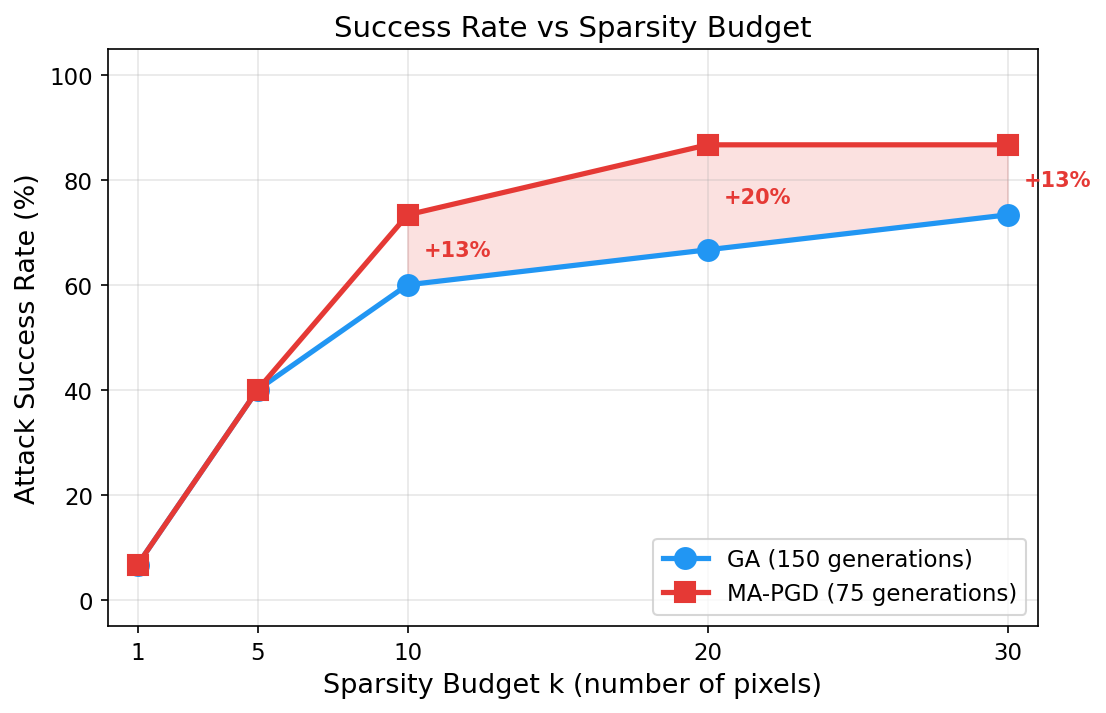

[Saved] results/plots/1_success_rate_vs_k.png


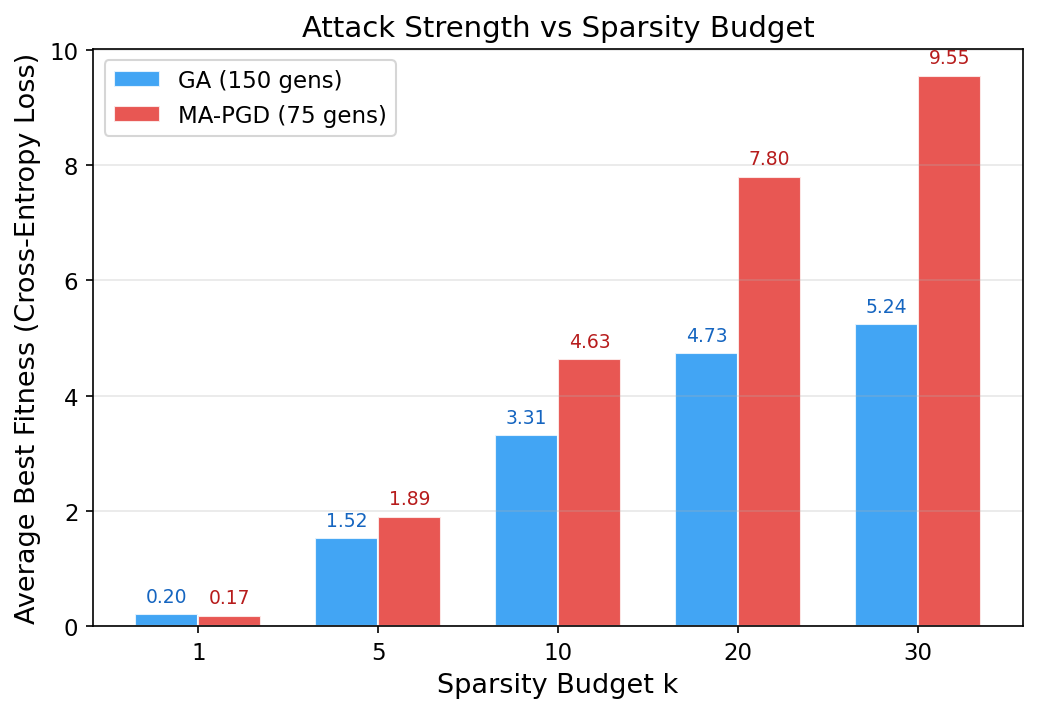

[Saved] results/plots/2_avg_fitness_vs_k.png


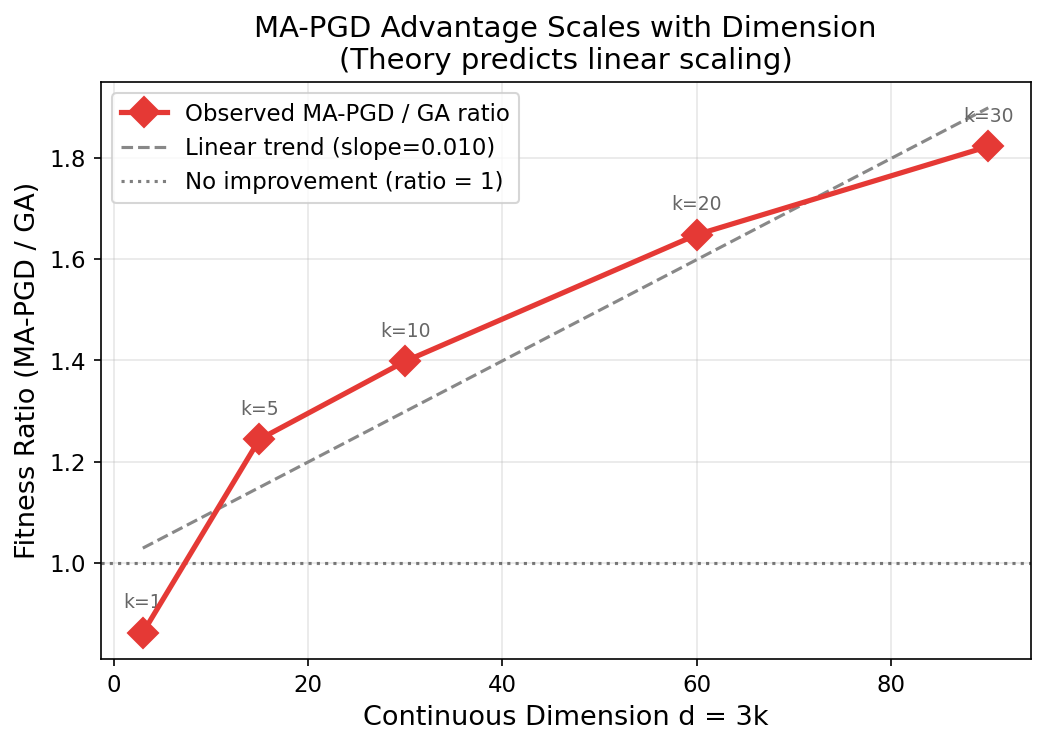

[Saved] results/plots/3_fitness_gain_vs_dimension.png


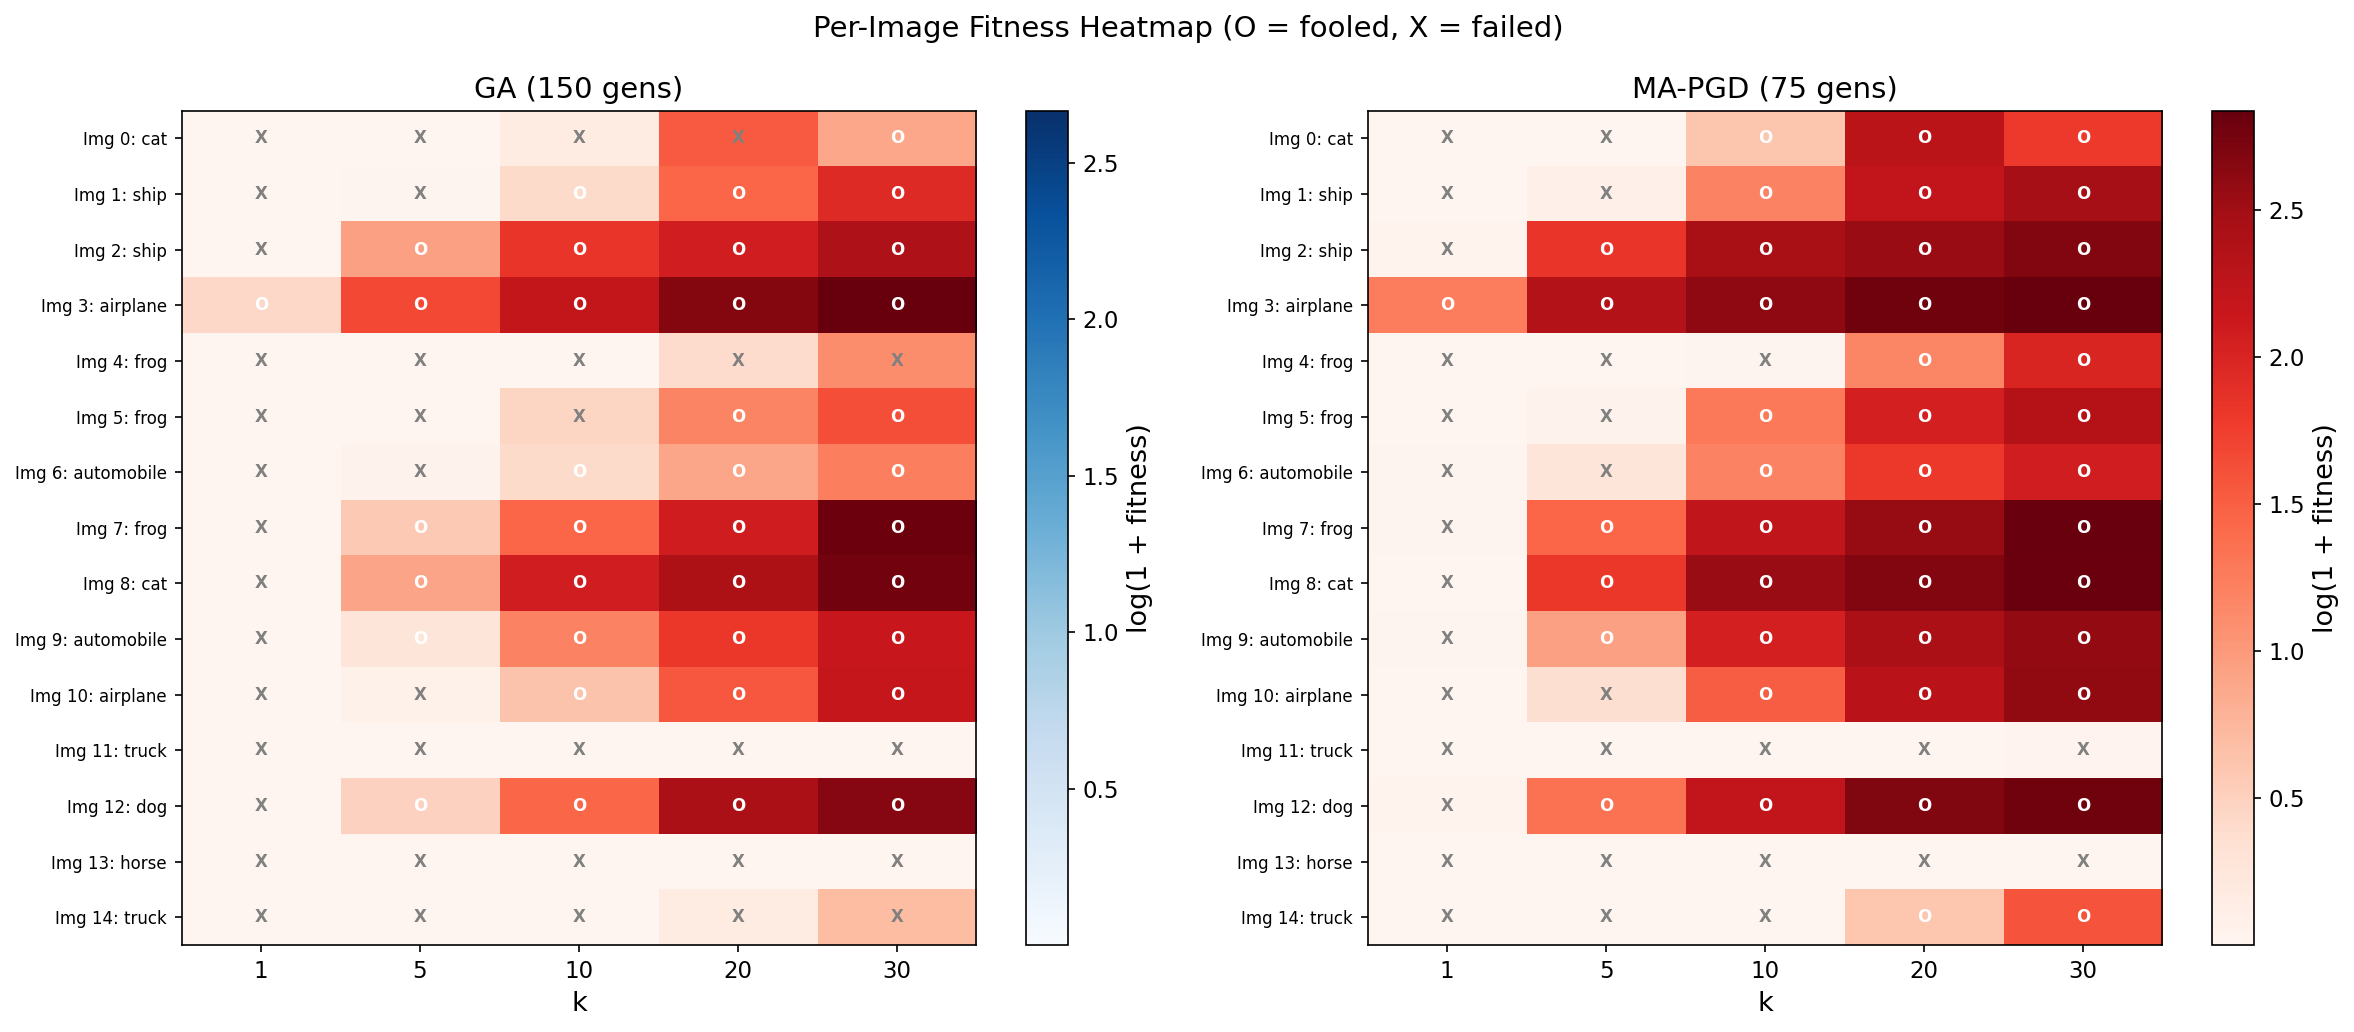

[Saved] results/plots/4_per_image_heatmap.png


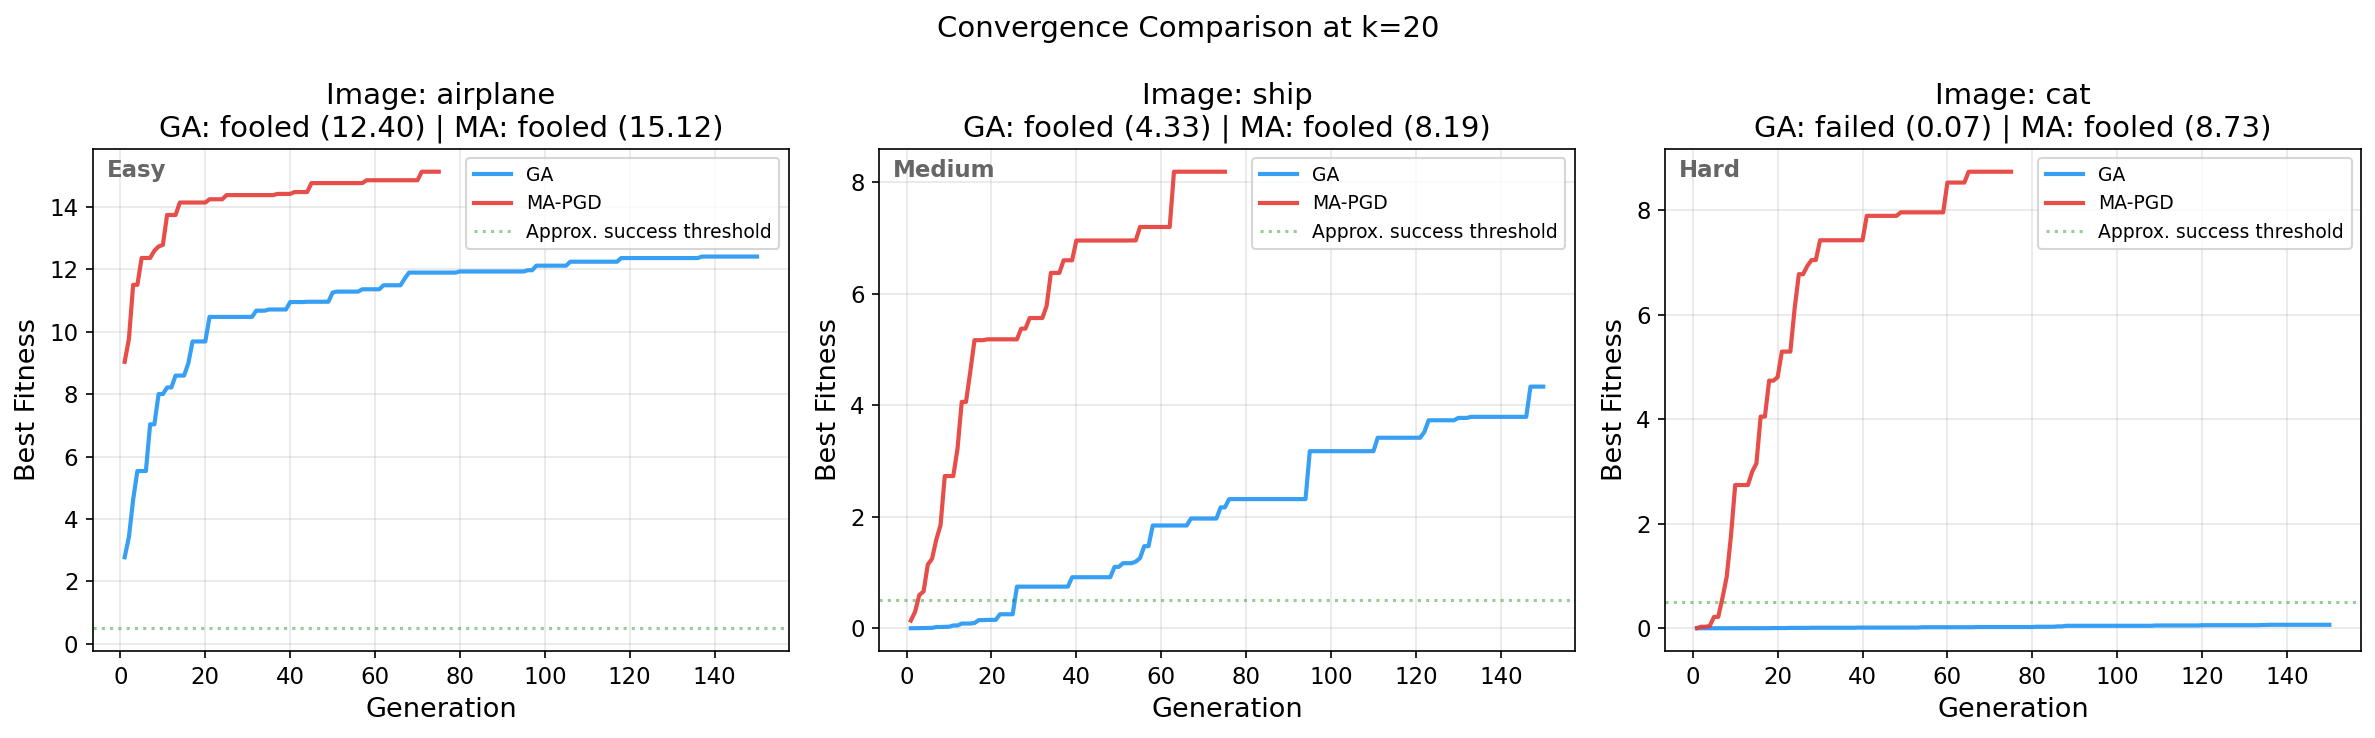

[Saved] results/plots/5_convergence_curves_k20.png


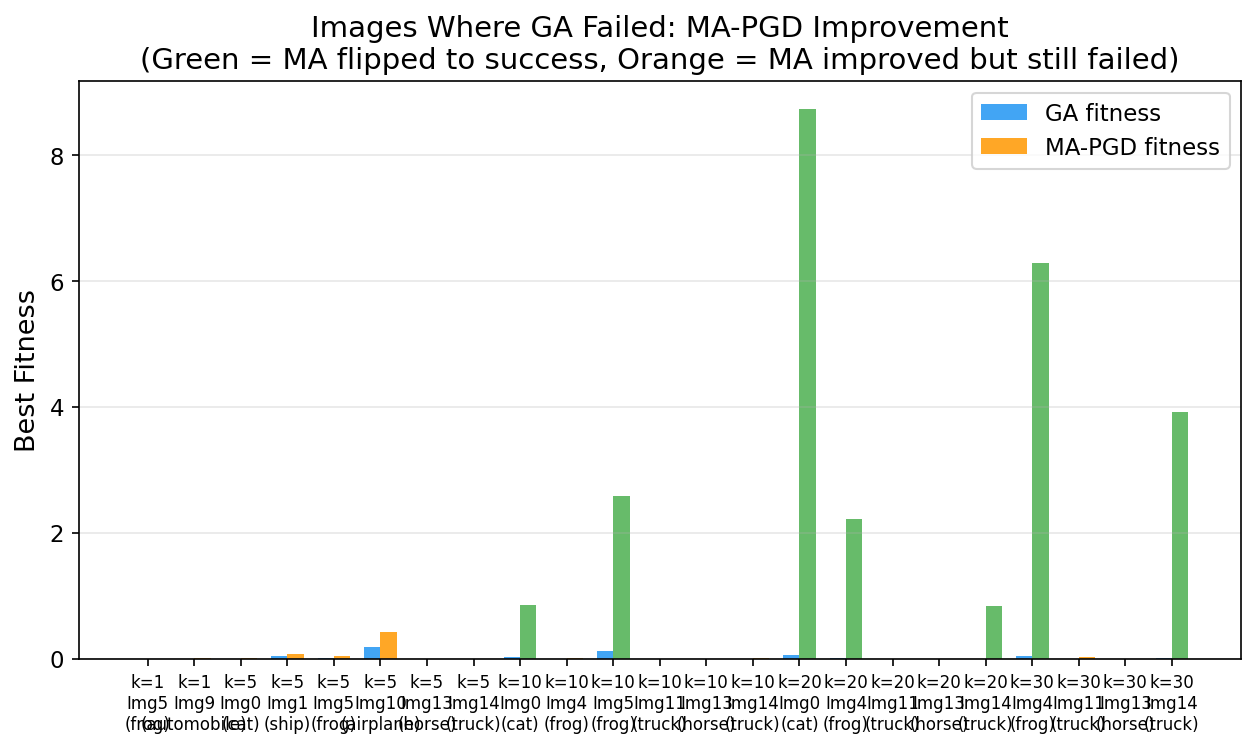

[Saved] results/plots/6_ga_failed_ma_improvement.png


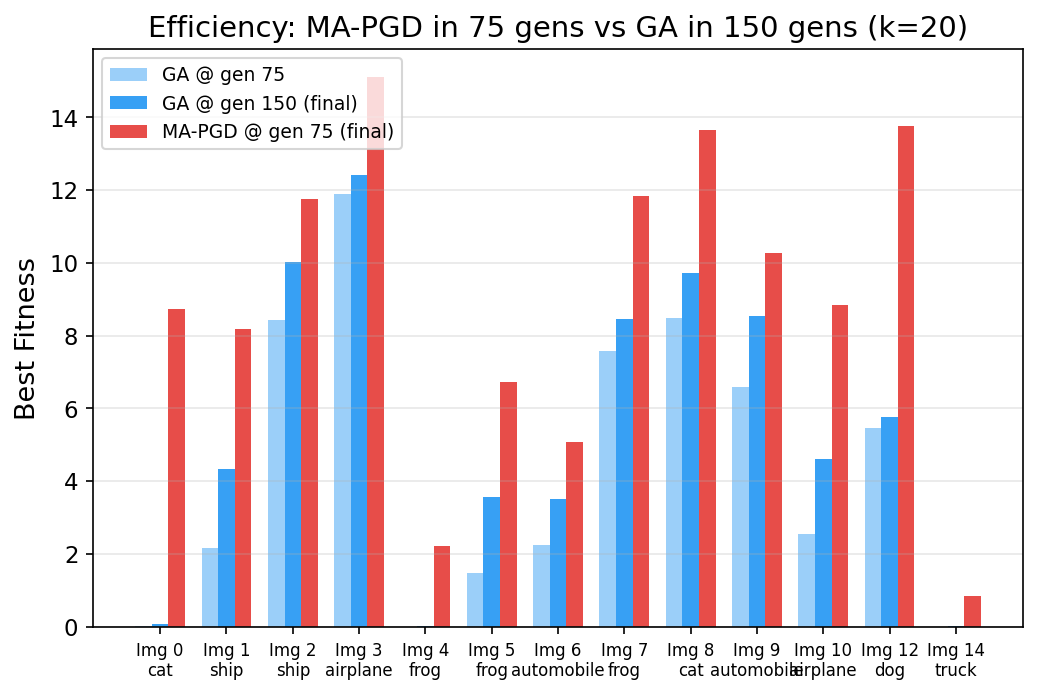

[Saved] results/plots/7_efficiency_comparison_k20.png


  COMPREHENSIVE RESULTS — GA vs MA-PGD

── Table 1: Success Rate and Fitness ──
   k | d=3k |    GA Rate |    MA Rate |    GA Fit |    MA Fit |   Gain
----------------------------------------------------------------------
   1 |    3 |  1/15 (  6.7%) |  1/15 (  6.7%) |    0.2016 |    0.1738 |   0.9x
   5 |   15 |  6/15 ( 40.0%) |  6/15 ( 40.0%) |    1.5212 |    1.8929 |   1.2x
  10 |   30 |  9/15 ( 60.0%) | 11/15 ( 73.3%) |    3.3106 |    4.6295 |   1.4x
  20 |   60 | 10/15 ( 66.7%) | 13/15 ( 86.7%) |    4.7323 |    7.8000 |   1.6x
  30 |   90 | 11/15 ( 73.3%) | 13/15 ( 86.7%) |    5.2383 |    9.5466 |   1.8x
----------------------------------------------------------------------
GA:     pop=80, gens=150, eps=0.1, black-box
MA-PGD: pop=80, gens=75,  eps=0.1, PGD 3 steps (white-box)
Note: MA-PGD uses HALF the generations of GA

── Table 2: Per-Image Results at k=20 ──
 Img |      Class |    GA Fit |    MA Fit |     GA |     MA |    

In [14]:
"""
================================================================================
GA vs MA-PGD: Comprehensive Comparison & Visualization
================================================================================

Generates:
  1. Success Rate vs k (main result plot)
  2. Average Fitness vs k
  3. Fitness Gain Factor vs k (showing scaling with dimension)
  4. Per-image comparison table (all k values)
  5. Convergence curves for selected images
  6. Summary statistics printed as LaTeX-ready tables

Run this AFTER both ga_attack and ma_pgd_attack have completed.
Loads results from results/ga_results.pt and results/ma_pgd_results.pt
================================================================================
"""

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import json
import os

matplotlib.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
})

CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

output_dir = "results/plots"
os.makedirs(output_dir, exist_ok=True)


# ══════════════════════════════════════════════════════════════════════
# LOAD RESULTS
# ══════════════════════════════════════════════════════════════════════

ga_data = torch.load("results/ga_results.pt", weights_only=False)
ma_data = torch.load("results/ma_pgd_results.pt", weights_only=False)

ga_res = ga_data["results"]
ma_res = ma_data["results"]
ga_cfg = ga_data["config"]
ma_cfg = ma_data["config"]

k_values = sorted([k for k in ga_res.keys() if isinstance(k, int)])
print(f"K values found: {k_values}")
print(f"GA config: pop={ga_cfg['pop_size']}, gens={ga_cfg['max_gens']}")
print(f"MA config: pop={ma_cfg['pop_size']}, gens={ma_cfg['max_gens']}, "
      f"pgd_steps={ma_cfg['pgd_steps']}")


# ══════════════════════════════════════════════════════════════════════
# 1. SUCCESS RATE vs k (MAIN RESULT)
# ══════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(8, 5))

ga_rates = [ga_res[k]["success_rate"] * 100 for k in k_values]
ma_rates = [ma_res[k]["success_rate"] * 100 for k in k_values]

ax.plot(k_values, ga_rates, 'o-', color='#2196F3', linewidth=2.5,
        markersize=10, label=f'GA (150 generations)', zorder=5)
ax.plot(k_values, ma_rates, 's-', color='#E53935', linewidth=2.5,
        markersize=10, label=f'MA-PGD (75 generations)', zorder=5)

# Shade the improvement region
ax.fill_between(k_values, ga_rates, ma_rates,
                alpha=0.15, color='#E53935',
                where=[m > g for m, g in zip(ma_rates, ga_rates)])

ax.set_xlabel('Sparsity Budget k (number of pixels)')
ax.set_ylabel('Attack Success Rate (%)')
ax.set_title('Success Rate vs Sparsity Budget')
ax.set_xticks(k_values)
ax.set_ylim(-5, 105)
ax.set_xlim(min(k_values) - 1, max(k_values) + 1)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

# Annotate key differences
for k, gr, mr in zip(k_values, ga_rates, ma_rates):
    if mr > gr:
        diff = mr - gr
        ax.annotate(f'+{diff:.0f}%',
                    xy=(k, (gr + mr) / 2), fontsize=10,
                    color='#E53935', fontweight='bold',
                    ha='left', va='center',
                    xytext=(8, 0), textcoords='offset points')

plt.savefig(f'{output_dir}/1_success_rate_vs_k.png')
plt.show()
print(f"[Saved] {output_dir}/1_success_rate_vs_k.png")


# ══════════════════════════════════════════════════════════════════════
# 2. AVERAGE FITNESS vs k
# ══════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(8, 5))

ga_fits = [ga_res[k]["avg_fitness"] for k in k_values]
ma_fits = [ma_res[k]["avg_fitness"] for k in k_values]

bars_x = np.arange(len(k_values))
width = 0.35

bars_ga = ax.bar(bars_x - width/2, ga_fits, width, color='#2196F3',
                 label='GA (150 gens)', alpha=0.85, edgecolor='white')
bars_ma = ax.bar(bars_x + width/2, ma_fits, width, color='#E53935',
                 label='MA-PGD (75 gens)', alpha=0.85, edgecolor='white')

# Add value labels on bars
for bar in bars_ga:
    h = bar.get_height()
    if h > 0.1:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.15,
                f'{h:.2f}', ha='center', va='bottom', fontsize=9,
                color='#1565C0')

for bar in bars_ma:
    h = bar.get_height()
    if h > 0.1:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.15,
                f'{h:.2f}', ha='center', va='bottom', fontsize=9,
                color='#B71C1C')

ax.set_xlabel('Sparsity Budget k')
ax.set_ylabel('Average Best Fitness (Cross-Entropy Loss)')
ax.set_title('Attack Strength vs Sparsity Budget')
ax.set_xticks(bars_x)
ax.set_xticklabels(k_values)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

plt.savefig(f'{output_dir}/2_avg_fitness_vs_k.png')
plt.show()
print(f"[Saved] {output_dir}/2_avg_fitness_vs_k.png")


# ══════════════════════════════════════════════════════════════════════
# 3. FITNESS GAIN FACTOR vs k (THEORETICAL PREDICTION)
# ══════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(8, 5))

gains = []
dimensions = []
for k in k_values:
    gf = ga_res[k]["avg_fitness"]
    mf = ma_res[k]["avg_fitness"]
    if gf > 0.01:
        gains.append(mf / gf)
    else:
        gains.append(float('nan'))
    dimensions.append(3 * k)  # d = 3k (RGB channels per pixel)

# Plot actual gains
valid = [(d, g) for d, g in zip(dimensions, gains) if not np.isnan(g)]
if valid:
    ds, gs = zip(*valid)
    ax.plot(ds, gs, 'D-', color='#E53935', linewidth=2.5,
            markersize=10, label='Observed MA-PGD / GA ratio', zorder=5)

    # Theoretical prediction: linear scaling with d
    # Fit a line through the data
    if len(ds) >= 2:
        coeffs = np.polyfit(ds, gs, 1)
        d_range = np.linspace(min(ds), max(ds), 100)
        ax.plot(d_range, np.polyval(coeffs, d_range), '--',
                color='#888888', linewidth=1.5,
                label=f'Linear trend (slope={coeffs[0]:.3f})')

ax.axhline(y=1.0, color='black', linestyle=':', alpha=0.5,
           label='No improvement (ratio = 1)')

ax.set_xlabel('Continuous Dimension d = 3k')
ax.set_ylabel('Fitness Ratio (MA-PGD / GA)')
ax.set_title('MA-PGD Advantage Scales with Dimension\n'
             '(Theory predicts linear scaling)')
ax.legend()
ax.grid(True, alpha=0.3)

# Add k labels on top
for d, g, k in zip(dimensions, gains, k_values):
    if not np.isnan(g):
        ax.annotate(f'k={k}', xy=(d, g), fontsize=9,
                    xytext=(0, 12), textcoords='offset points',
                    ha='center', color='#666666')

plt.savefig(f'{output_dir}/3_fitness_gain_vs_dimension.png')
plt.show()
print(f"[Saved] {output_dir}/3_fitness_gain_vs_dimension.png")


# ══════════════════════════════════════════════════════════════════════
# 4. PER-IMAGE COMPARISON HEATMAP
# ══════════════════════════════════════════════════════════════════════

num_imgs = ga_res[k_values[0]]["num_images"]

# Build comparison matrix: 1 = both succeed, 0.5 = MA only, -0.5 = GA only, 0 = both fail
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax_idx, (data, title, cmap_name) in enumerate([
    (ga_res, "GA (150 gens)", "Blues"),
    (ma_res, "MA-PGD (75 gens)", "Reds"),
]):
    matrix = np.zeros((num_imgs, len(k_values)))
    img_labels = []

    for j, k in enumerate(k_values):
        for i, img_r in enumerate(data[k]["per_image"]):
            matrix[i, j] = img_r["best_fitness"]
            if j == 0:
                img_labels.append(f"Img {img_r['img_idx']}: {img_r['true_class']}")

    im = ax.imshow(matrix, aspect='auto', cmap=cmap_name)
    ax = axes[ax_idx]
    im = ax.imshow(np.log1p(matrix), aspect='auto', cmap=cmap_name,
                   interpolation='nearest')

    ax.set_xticks(range(len(k_values)))
    ax.set_xticklabels(k_values)
    ax.set_yticks(range(num_imgs))
    ax.set_yticklabels(img_labels, fontsize=8)
    ax.set_xlabel('k')
    ax.set_title(title)

    # Add success/fail markers
    for j, k in enumerate(k_values):
        for i, img_r in enumerate(data[k]["per_image"]):
            marker = "O" if img_r["success"] else "X"
            color = "white" if img_r["success"] else "gray"
            ax.text(j, i, marker, ha='center', va='center',
                    fontsize=8, fontweight='bold', color=color)

    plt.colorbar(im, ax=ax, label='log(1 + fitness)')

plt.suptitle('Per-Image Fitness Heatmap (O = fooled, X = failed)', fontsize=14)
plt.tight_layout()
plt.savefig(f'{output_dir}/4_per_image_heatmap.png')
plt.show()
print(f"[Saved] {output_dir}/4_per_image_heatmap.png")


# ══════════════════════════════════════════════════════════════════════
# 5. CONVERGENCE CURVES (selected images)
# ══════════════════════════════════════════════════════════════════════

# Pick representative images: one easy, one medium, one hard
# Image 4 (airplane) = easy, Image 2 (ship) = medium, Image 1 (cat) = hard
selected_images = [3, 1, 0]  # indices into per_image arrays
selected_k = 20  # k where the difference is most visible

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax_idx, img_idx in enumerate(selected_images):
    ax = axes[ax_idx]

    ga_conv = ga_res[selected_k]["per_image"][img_idx]["convergence"]
    ma_conv = ma_res[selected_k]["per_image"][img_idx]["convergence"]

    ga_gens = [c["gen"] for c in ga_conv]
    ga_best = [c["best_fit"] for c in ga_conv]
    ma_gens = [c["gen"] for c in ma_conv]
    ma_best = [c["best_fit"] for c in ma_conv]

    img_class = ga_res[selected_k]["per_image"][img_idx]["true_class"]
    ga_success = ga_res[selected_k]["per_image"][img_idx]["success"]
    ma_success = ma_res[selected_k]["per_image"][img_idx]["success"]

    ax.plot(ga_gens, ga_best, '-', color='#2196F3', linewidth=2,
            label='GA', alpha=0.9)
    ax.plot(ma_gens, ma_best, '-', color='#E53935', linewidth=2,
            label='MA-PGD', alpha=0.9)

    # Mark success threshold (roughly loss > 0.5 means likely misclassification)
    ax.axhline(y=0.5, color='green', linestyle=':', alpha=0.4,
               label='Approx. success threshold')

    ga_tag = "fooled" if ga_success else "failed"
    ma_tag = "fooled" if ma_success else "failed"
    ax.set_title(f'Image: {img_class}\n'
                 f'GA: {ga_tag} ({ga_best[-1]:.2f}) | '
                 f'MA: {ma_tag} ({ma_best[-1]:.2f})')
    ax.set_xlabel('Generation')
    ax.set_ylabel('Best Fitness')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

difficulty = ['Easy', 'Medium', 'Hard']
for ax_idx, d in enumerate(difficulty):
    axes[ax_idx].text(0.02, 0.98, d, transform=axes[ax_idx].transAxes,
                      fontsize=11, fontweight='bold', va='top',
                      color='#666666')

plt.suptitle(f'Convergence Comparison at k={selected_k}', fontsize=14)
plt.tight_layout()
plt.savefig(f'{output_dir}/5_convergence_curves_k{selected_k}.png')
plt.show()
print(f"[Saved] {output_dir}/5_convergence_curves_k{selected_k}.png")


# ══════════════════════════════════════════════════════════════════════
# 6. GA-FAILED IMAGES: WHAT DID MA-PGD ACHIEVE?
# ══════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(10, 5))

# For each k, find images where GA failed but MA succeeded
k_labels = []
ga_fit_vals = []
ma_fit_vals = []
bar_colors = []

for k in k_values:
    ga_imgs = ga_res[k]["per_image"]
    ma_imgs = ma_res[k]["per_image"]

    for i in range(len(ga_imgs)):
        if not ga_imgs[i]["success"]:
            gf = ga_imgs[i]["best_fitness"]
            mf = ma_imgs[i]["best_fitness"]
            flipped = ma_imgs[i]["success"]

            if mf > gf * 2 or flipped:  # only show interesting cases
                label = f"k={k}\nImg{ga_imgs[i]['img_idx']}\n({ga_imgs[i]['true_class']})"
                k_labels.append(label)
                ga_fit_vals.append(gf)
                ma_fit_vals.append(mf)
                bar_colors.append('#4CAF50' if flipped else '#FF9800')

if k_labels:
    x = np.arange(len(k_labels))
    width = 0.35

    ax.bar(x - width/2, ga_fit_vals, width, color='#2196F3',
           label='GA fitness', alpha=0.85)
    ax.bar(x + width/2, ma_fit_vals, width, color=bar_colors,
           label='MA-PGD fitness', alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(k_labels, fontsize=8)
    ax.set_ylabel('Best Fitness')
    ax.set_title('Images Where GA Failed: MA-PGD Improvement\n'
                 '(Green = MA flipped to success, Orange = MA improved but still failed)')
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)

plt.savefig(f'{output_dir}/6_ga_failed_ma_improvement.png')
plt.show()
print(f"[Saved] {output_dir}/6_ga_failed_ma_improvement.png")


# ══════════════════════════════════════════════════════════════════════
# 7. EFFICIENCY COMPARISON (generations needed)
# ══════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(8, 5))

# For successful attacks, compare fitness at gen 75 (MA's budget) vs gen 150 (GA's budget)
k_plot = 20  # most interesting k value

ga_imgs = ga_res[k_plot]["per_image"]
ma_imgs = ma_res[k_plot]["per_image"]

ga_75_fits = []
ga_150_fits = []
ma_75_fits = []
img_names = []

for i in range(len(ga_imgs)):
    ga_conv = ga_imgs[i]["convergence"]
    ma_conv = ma_imgs[i]["convergence"]

    # GA fitness at gen 75 (halfway) and gen 150 (final)
    ga_at_75 = ga_conv[74]["best_fit"] if len(ga_conv) > 74 else ga_conv[-1]["best_fit"]
    ga_at_150 = ga_conv[-1]["best_fit"]
    ma_at_75 = ma_conv[-1]["best_fit"]

    if ga_at_150 > 0.1 or ma_at_75 > 0.1:  # skip boring zero images
        ga_75_fits.append(ga_at_75)
        ga_150_fits.append(ga_at_150)
        ma_75_fits.append(ma_at_75)
        img_names.append(f"Img {ga_imgs[i]['img_idx']}\n{ga_imgs[i]['true_class']}")

if img_names:
    x = np.arange(len(img_names))
    width = 0.25

    ax.bar(x - width, ga_75_fits, width, color='#90CAF9',
           label='GA @ gen 75', alpha=0.9)
    ax.bar(x, ga_150_fits, width, color='#2196F3',
           label='GA @ gen 150 (final)', alpha=0.9)
    ax.bar(x + width, ma_75_fits, width, color='#E53935',
           label='MA-PGD @ gen 75 (final)', alpha=0.9)

    ax.set_xticks(x)
    ax.set_xticklabels(img_names, fontsize=8)
    ax.set_ylabel('Best Fitness')
    ax.set_title(f'Efficiency: MA-PGD in 75 gens vs GA in 150 gens (k={k_plot})')
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)

plt.savefig(f'{output_dir}/7_efficiency_comparison_k{k_plot}.png')
plt.show()
print(f"[Saved] {output_dir}/7_efficiency_comparison_k{k_plot}.png")


# ══════════════════════════════════════════════════════════════════════
# 8. COMPREHENSIVE SUMMARY TABLES (print to console)
# ══════════════════════════════════════════════════════════════════════

print("\n")
print("=" * 80)
print("  COMPREHENSIVE RESULTS — GA vs MA-PGD")
print("=" * 80)

# Table 1: Main results
print("\n── Table 1: Success Rate and Fitness ──")
print(f"{'k':>4s} | {'d=3k':>4s} | {'GA Rate':>10s} | {'MA Rate':>10s} | "
      f"{'GA Fit':>9s} | {'MA Fit':>9s} | {'Gain':>6s}")
print("-" * 70)

for k in k_values:
    d = 3 * k
    g = ga_res[k]
    m = ma_res[k]
    gr = g['success_rate'] * 100
    mr = m['success_rate'] * 100
    gf = g['avg_fitness']
    mf = m['avg_fitness']
    gain = mf / gf if gf > 0.01 else float('inf')
    gain_str = f"{gain:.1f}x" if gain < 100 else ">>1"

    print(f"{k:4d} | {d:4d} | "
          f"{g['num_success']:2d}/15 ({gr:5.1f}%) | "
          f"{m['num_success']:2d}/15 ({mr:5.1f}%) | "
          f"{gf:9.4f} | {mf:9.4f} | {gain_str:>6s}")

print("-" * 70)
print(f"GA:     pop=80, gens=150, eps=0.1, black-box")
print(f"MA-PGD: pop=80, gens=75,  eps=0.1, PGD 3 steps (white-box)")
print(f"Note: MA-PGD uses HALF the generations of GA")

# Table 2: Per-image at k=20
print(f"\n── Table 2: Per-Image Results at k=20 ──")
print(f"{'Img':>4s} | {'Class':>10s} | {'GA Fit':>9s} | {'MA Fit':>9s} | "
      f"{'GA':>6s} | {'MA':>6s} | {'Gain':>8s}")
print("-" * 68)

for i in range(num_imgs):
    gi = ga_res[20]["per_image"][i]
    mi = ma_res[20]["per_image"][i]
    gf = gi["best_fitness"]
    mf = mi["best_fitness"]

    if gf > 0.001:
        gain = f"{mf/gf:.1f}x"
    elif mf > 0.001:
        gain = f">{mf:.1f}"
    else:
        gain = "both~0"

    print(f"{gi['img_idx']:4d} | {gi['true_class']:>10s} | "
          f"{gf:9.4f} | {mf:9.4f} | "
          f"{'OK' if gi['success'] else 'FAIL':>6s} | "
          f"{'OK' if mi['success'] else 'FAIL':>6s} | "
          f"{gain:>8s}")

# Table 3: Flipped images (GA failed, MA succeeded)
print(f"\n── Table 3: Images Flipped by MA-PGD (GA failed → MA succeeded) ──")
print(f"{'k':>4s} | {'Img':>4s} | {'Class':>10s} | {'GA Fit':>9s} | "
      f"{'MA Fit':>9s} | {'Improvement':>12s}")
print("-" * 62)

flipped_count = 0
for k in k_values:
    ga_imgs = ga_res[k]["per_image"]
    ma_imgs = ma_res[k]["per_image"]
    for i in range(len(ga_imgs)):
        if not ga_imgs[i]["success"] and ma_imgs[i]["success"]:
            gf = ga_imgs[i]["best_fitness"]
            mf = ma_imgs[i]["best_fitness"]
            imp = f"{mf/gf:.0f}x" if gf > 0.001 else "from ~0"
            print(f"{k:4d} | {ga_imgs[i]['img_idx']:4d} | "
                  f"{ga_imgs[i]['true_class']:>10s} | "
                  f"{gf:9.4f} | {mf:9.4f} | {imp:>12s}")
            flipped_count += 1

print(f"\nTotal flipped: {flipped_count} instances across all k values")

# Table 4: Key statistics
print(f"\n── Table 4: Key Statistics ──")
total_ga_success = sum(ga_res[k]["num_success"] for k in k_values)
total_ma_success = sum(ma_res[k]["num_success"] for k in k_values)
total_tests = len(k_values) * num_imgs

print(f"  Total attack instances:     {total_tests}")
print(f"  GA total successes:         {total_ga_success}/{total_tests} "
      f"({100*total_ga_success/total_tests:.1f}%)")
print(f"  MA-PGD total successes:     {total_ma_success}/{total_tests} "
      f"({100*total_ma_success/total_tests:.1f}%)")
print(f"  MA-PGD extra successes:     {total_ma_success - total_ga_success}")
print(f"  GA generations used:        150")
print(f"  MA-PGD generations used:    75 (2x fewer)")
print(f"  MA-PGD PGD steps/child:     3")
print(f"  Fitness gain at k=10:       {ma_res[10]['avg_fitness']/ga_res[10]['avg_fitness']:.2f}x")
print(f"  Fitness gain at k=20:       {ma_res[20]['avg_fitness']/ga_res[20]['avg_fitness']:.2f}x")
print(f"  Fitness gain at k=30:       {ma_res[30]['avg_fitness']/ga_res[30]['avg_fitness']:.2f}x")

print(f"\n{'='*80}")
print(f"  All plots saved to {output_dir}/")
print(f"{'='*80}")

In [16]:
import torch
import numpy as np
from scipy import stats

ga_data = torch.load("results/ga_results.pt", weights_only=False)
ma_data = torch.load("results/ma_pgd_results.pt", weights_only=False)
ga_res = ga_data["results"]
ma_res = ma_data["results"]
k_values = sorted([k for k in ga_res.keys() if isinstance(k, int)])

print("=" * 75)
print("  WILCOXON SIGNED-RANK TEST: GA vs MA-PGD")
print("=" * 75)
print("  H0: median(MA_fitness - GA_fitness) = 0")
print("  H1: median(MA_fitness - GA_fitness) > 0  (MA is better)")
print()
print(f"  {'k':>4s} | {'GA Mean':>9s} | {'MA Mean':>9s} | {'Mean Diff':>10s} | "
      f"{'Statistic':>9s} | {'p-value':>9s} | {'Significant':>11s}")
print(f"  {'-'*73}")

for k in k_values:
    ga_fits = [img["best_fitness"] for img in ga_res[k]["per_image"]]
    ma_fits = [img["best_fitness"] for img in ma_res[k]["per_image"]]
    diffs = [m - g for g, m in zip(ga_fits, ma_fits)]

    nonzero = [(g, m) for g, m in zip(ga_fits, ma_fits) if abs(m - g) > 1e-6]

    if len(nonzero) >= 5:
        stat, p_val = stats.wilcoxon(
            [x[1] for x in nonzero],
            [x[0] for x in nonzero],
            alternative='greater'
        )
        sig = "YES (p<0.05)" if p_val < 0.05 else "NO"
    else:
        stat, p_val = float('nan'), float('nan')
        sig = "too few pairs"

    print(f"  {k:4d} | {np.mean(ga_fits):9.4f} | {np.mean(ma_fits):9.4f} | "
          f"{np.mean(diffs):+10.4f} | {stat:9.1f} | {p_val:9.4f} | {sig:>11s}")

# Overall (all k values pooled)
all_ga = []
all_ma = []
for k in k_values:
    for img in ga_res[k]["per_image"]:
        all_ga.append(img["best_fitness"])
    for img in ma_res[k]["per_image"]:
        all_ma.append(img["best_fitness"])

nonzero_all = [(g, m) for g, m in zip(all_ga, all_ma) if abs(m - g) > 1e-6]
stat_all, p_all = stats.wilcoxon(
    [x[1] for x in nonzero_all],
    [x[0] for x in nonzero_all],
    alternative='greater'
)

print(f"  {'-'*73}")
print(f"  {'ALL':>4s} | {np.mean(all_ga):9.4f} | {np.mean(all_ma):9.4f} | "
      f"{np.mean([m-g for g,m in zip(all_ga,all_ma)]):+10.4f} | "
      f"{stat_all:9.1f} | {p_all:9.6f} | "
      f"{'YES (p<0.05)' if p_all < 0.05 else 'NO':>11s}")
print(f"  {'-'*73}")
print(f"  Significance level: alpha = 0.05, one-sided test")
print(f"  Total paired instances: {len(all_ga)}")

  WILCOXON SIGNED-RANK TEST: GA vs MA-PGD
  H0: median(MA_fitness - GA_fitness) = 0
  H1: median(MA_fitness - GA_fitness) > 0  (MA is better)

     k |   GA Mean |   MA Mean |  Mean Diff | Statistic |   p-value | Significant
  -------------------------------------------------------------------------
     1 |    0.2016 |    0.1738 |    -0.0277 |      45.0 |    0.1602 |          NO
     5 |    1.5212 |    1.8929 |    +0.3717 |     102.0 |    0.0075 | YES (p<0.05)
    10 |    3.3106 |    4.6295 |    +1.3189 |     120.0 |    0.0000 | YES (p<0.05)
    20 |    4.7323 |    7.8000 |    +3.0678 |     120.0 |    0.0000 | YES (p<0.05)
    30 |    5.2383 |    9.5466 |    +4.3084 |     120.0 |    0.0000 | YES (p<0.05)
  -------------------------------------------------------------------------
   ALL |    3.0008 |    4.8086 |    +1.8078 |    2448.0 |  0.000000 | YES (p<0.05)
  -------------------------------------------------------------------------
  Significance level: alpha = 0.05, one-sided test